In [4]:
import os
os.chdir(r'C:\Users\hdped\Desktop\ANTAQ_Projeto - Copia')

In [5]:
%matplotlib inline

In [6]:
"""
Fleet Deployment Analysis — Vessels Master Enriched
Shipping Lines no mercado brasileiro

LIMITAÇÃO: análise estática de frota registada. Sem dados AIS.
Não é equivalente a deployment real nem movimentação efectiva.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import os

# ─── CONFIG ───────────────────────────────────────────────────────────────────
FILE    = 'data/02_Operacoes/Vessels_Master_Enriched.csv'
FIGDIR  = 'outputs/figures'
CSVDIR  = 'outputs/processed_data'

CORES = {
    'COSCO':       '#003087',
    'MAERSK':      '#005AA0',
    'CMA CGM':     '#E30613',
    'MSC':         '#004F9F',
    'EVERGREEN':   '#00693C',
    'Hapag-Lloyd': '#F26722',
    'ONE':         '#E4003A',
    'ZIM':         '#00A3E0',
}

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(CSVDIR, exist_ok=True)


# ─── 1. LOAD & DIAGNÓSTICO ────────────────────────────────────────────────────
df = pd.read_csv(FILE, encoding='utf-8-sig', low_memory=False)
df.columns = df.columns.str.strip()

print('=== DIAGNÓSTICO DE QUALIDADE DOS DADOS ===')
print(f'Total de registos : {len(df):,}')
print(f'Shipping lines    : {df["SHIPPING LINE"].nunique()}')
print()

nulls = df.isnull().sum()
pct   = (nulls / len(df) * 100).round(1)
diag  = pd.DataFrame({'nulos': nulls, 'pct_%': pct})
diag  = diag[diag['nulos'] > 0].sort_values('nulos', ascending=False)
print('Campos com valores nulos:')
print(diag.to_string())
print()
print('Campos 100% nulos (inutilizáveis):', [c for c in df.columns if df[c].isna().all()])
print()

# Anomalias: TEU > 24.000
teu_max = df[df['CAPACIDADE (TEU)'] > 24000]
print(f'Navios com TEU > 24.000 (ULCVs extremos): {len(teu_max)}')

# year_built futuro -> tratar como nulo
n_future = (df['year_built'] > 2025).sum()
print(f'Navios com year_built > 2025 (em construção): {n_future} — tratados como nulos')
df.loc[df['year_built'] > 2025, 'year_built'] = np.nan

# Calcular idade
df['idade'] = 2025 - df['year_built']


# ─── Q1: CAPACIDADE TOTAL (TEU) POR SHIPPING LINE ─────────────────────────────
# TEU total = soma da capacidade nominal de todos os navios do carrier
# NÃO é TEU movimentado — é frota registada neste dataset

q1 = (df.groupby('SHIPPING LINE')
        .agg(
            n_navios      = ('NÚMERO IMO',         'count'),
            teu_total     = ('CAPACIDADE (TEU)',    'sum'),
            teu_medio     = ('CAPACIDADE (TEU)',    'mean'),
            teu_max_navio = ('CAPACIDADE (TEU)',    'max'),
        )
        .sort_values('teu_total', ascending=False)
        .round(0).astype(int))

q1['market_share_pct'] = (q1['teu_total'] / q1['teu_total'].sum() * 100).round(1)
q1['rank'] = range(1, len(q1) + 1)

print('\n=== Q1 — TEU TOTAL POR CARRIER ===')
print(q1[['rank', 'n_navios', 'teu_total', 'teu_medio', 'market_share_pct']].to_string())

q1.reset_index().to_csv(f'{CSVDIR}/fleet_q1_teu_por_carrier.csv', index=False, encoding='utf-8-sig')

# Figura Q1
q1_plot = q1.sort_values('teu_total', ascending=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Q1 — Capacidade Total por Shipping Line (Frota Registada)',
             fontsize=13, fontweight='bold')

carriers = q1_plot.index.tolist()
colors   = [CORES.get(c, '#888888') for c in carriers]
x        = range(len(carriers))

bars = ax1.barh(x, q1_plot['teu_total'], color=colors, alpha=0.88)
ax1.set_yticks(x); ax1.set_yticklabels(carriers)
ax1.set_xlabel('Capacidade Total (TEU)')
ax1.set_title('TEU Total por Carrier')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v/1e6:.1f}M'))
for bar, val in zip(bars, q1_plot['teu_total']):
    ax1.text(bar.get_width() + 15000, bar.get_y() + bar.get_height() / 2,
             f'{val/1e6:.2f}M', va='center', fontsize=8.5)

bottom = 0
for c, row in q1.iterrows():
    pct = row['market_share_pct']
    ax2.bar(0, pct, bottom=bottom, color=CORES.get(c, '#888'), alpha=0.88,
            label=f'{c} ({pct:.1f}%)', width=0.5)
    if pct > 3:
        ax2.text(0, bottom + pct / 2, f'{c}\n{pct:.1f}%',
                 ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += pct
ax2.set_xlim(-0.5, 0.5); ax2.set_xticks([])
ax2.set_ylabel('Market Share (%)'); ax2.set_title('Distribuição de Market Share')
ax2.set_ylim(0, 103)

plt.tight_layout()
plt.savefig(f'{FIGDIR}/fleet_q1_teu_carrier.png', bbox_inches='tight', dpi=150)
plt.close()
print('Figura Q1 salva.')


# ─── Q2: PERFIL MÉDIO DE FROTA POR CARRIER ────────────────────────────────────
# TEU médio  = tamanho típico do navio (maior = estratégia mainline)
# Idade média = anos desde construção (nova < 10 anos)
# Segmento dominante = categoria com mais navios no portfolio

seg_dom = (df.groupby(['SHIPPING LINE', 'vessel_segment'])
             .size().reset_index(name='n')
             .sort_values('n', ascending=False)
             .groupby('SHIPPING LINE').first()['vessel_segment'])

q2 = (df.groupby('SHIPPING LINE')
        .agg(
            n_navios       = ('NÚMERO IMO',         'count'),
            teu_medio      = ('CAPACIDADE (TEU)',    'mean'),
            teu_std        = ('CAPACIDADE (TEU)',    'std'),
            idade_media    = ('idade',               'mean'),
            idade_mediana  = ('idade',               'median'),
            pct_miss_idade = ('year_built',          lambda x: x.isna().mean() * 100),
            loa_media      = ('loa',                 'mean'),
        )
        .round(1))
q2['segmento_dominante'] = seg_dom
q2 = q2.sort_values('teu_medio', ascending=False)

print('\n=== Q2 — PERFIL DE FROTA POR CARRIER ===')
print(q2.to_string())

q2.reset_index().to_csv(f'{CSVDIR}/fleet_q2_perfil_carrier.csv', index=False, encoding='utf-8-sig')

# Figura Q2
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Q2 — Perfil de Frota por Carrier', fontsize=13, fontweight='bold')

carriers = q2.index.tolist()
colors   = [CORES.get(c, '#888') for c in carriers]
x        = range(len(carriers))

bars = axes[0].bar(x, q2['teu_medio'], color=colors, alpha=0.88)
axes[0].set_xticks(x); axes[0].set_xticklabels(carriers, rotation=35, ha='right', fontsize=8.5)
axes[0].set_ylabel('TEU Médio por Navio'); axes[0].set_title('Tamanho Médio do Navio')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v/1000:.0f}k'))
for bar, val in zip(bars, q2['teu_medio']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=7.5)

q2_age = q2.sort_values('idade_media', ascending=False)
colors2 = [CORES.get(c, '#888') for c in q2_age.index]
bars2 = axes[1].bar(range(len(q2_age)), q2_age['idade_media'], color=colors2, alpha=0.88)
axes[1].set_xticks(range(len(q2_age)))
axes[1].set_xticklabels(q2_age.index, rotation=35, ha='right', fontsize=8.5)
axes[1].set_ylabel('Idade Média (anos)'); axes[1].set_title('Idade Média da Frota')
axes[1].axhline(10, color='green', linestyle='--', alpha=0.5, label='10 anos')
axes[1].axhline(20, color='red',   linestyle='--', alpha=0.5, label='20 anos')
axes[1].legend(fontsize=8)
for bar, val in zip(bars2, q2_age['idade_media']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                 f'{val:.1f}a', ha='center', va='bottom', fontsize=8)

for c, row in q2.iterrows():
    axes[2].scatter(row['idade_media'], row['teu_medio'],
                    s=row['n_navios'] * 1.2, color=CORES.get(c, '#888'),
                    alpha=0.8, edgecolors='white', linewidth=0.5)
    axes[2].annotate(c, (row['idade_media'], row['teu_medio']),
                     textcoords='offset points', xytext=(5, 4), fontsize=8)
axes[2].set_xlabel('Idade Média (anos)'); axes[2].set_ylabel('TEU Médio por Navio')
axes[2].set_title('Capacidade vs Idade\n(tamanho = nº navios)')
axes[2].axvline(15, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{FIGDIR}/fleet_q2_perfil_carrier.png', bbox_inches='tight', dpi=150)
plt.close()
print('Figura Q2 salva.')


# ─── Q3: HHI POR VESSEL SEGMENT ───────────────────────────────────────────────
# HHI = Σ(share_i²) × 10.000
# HHI < 1.500  = competitivo
# HHI 1.500–2.500 = moderadamente concentrado
# HHI > 2.500  = altamente concentrado (risco antitruste)
# Métrica usada: capacidade TEU (não movimentação real)

seg_carrier = (df.groupby(['vessel_segment', 'SHIPPING LINE'])['CAPACIDADE (TEU)']
               .sum().reset_index(name='teu'))
seg_total   = seg_carrier.groupby('vessel_segment')['teu'].sum().rename('tot')
seg_carrier = seg_carrier.merge(seg_total, on='vessel_segment')
seg_carrier['share']    = seg_carrier['teu'] / seg_carrier['tot']
seg_carrier['share_sq'] = seg_carrier['share'] ** 2

hhi = (seg_carrier.groupby('vessel_segment')['share_sq']
       .sum().multiply(10000).round(0).astype(int)
       .reset_index().rename(columns={'share_sq': 'HHI'}))

def interpret_hhi(h):
    if h < 1500: return 'Competitivo'
    if h < 2500: return 'Moderadamente concentrado'
    return 'Altamente concentrado'

hhi['interpretacao'] = hhi['HHI'].apply(interpret_hhi)

seg_order = ['Feeder Max (1k-3k TEU)', 'Sub-Panamax (3k-8k TEU)',
             'Post-Panamax (8k-12k TEU)', 'New Panamax (12k-18k TEU)',
             'Ultra Large (> 18k TEU)']
hhi['vessel_segment'] = pd.Categorical(hhi['vessel_segment'], categories=seg_order, ordered=True)
hhi = hhi.sort_values('vessel_segment')

print('\n=== Q3 — HHI POR SEGMENTO ===')
print(hhi.to_string(index=False))
print('\nTop 2 carriers por segmento:')
for seg in seg_order:
    top2 = (seg_carrier[seg_carrier['vessel_segment'] == seg]
            .sort_values('share', ascending=False).head(2))
    s = ' | '.join([f"{r['SHIPPING LINE']}: {r['share']*100:.1f}%" for _, r in top2.iterrows()])
    print(f'  {seg[:28]:28s}  {s}')

hhi.to_csv(f'{CSVDIR}/fleet_q3_hhi_segmento.csv', index=False, encoding='utf-8-sig')

# Figura Q3
seg_labels = ['Feeder Max\n(1k-3k)', 'Sub-Panamax\n(3k-8k)',
              'Post-Panamax\n(8k-12k)', 'New Panamax\n(12k-18k)', 'Ultra Large\n(>18k)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q3 — Concentração de Mercado (HHI) por Segmento de Frota',
             fontsize=13, fontweight='bold')

x = np.arange(len(seg_order))
bottom = np.zeros(len(seg_order))
carriers_order = ['COSCO', 'MSC', 'MAERSK', 'CMA CGM', 'EVERGREEN', 'Hapag-Lloyd', 'ONE', 'ZIM']

for c in carriers_order:
    vals = []
    for seg in seg_order:
        row = seg_carrier[(seg_carrier['vessel_segment'] == seg) & (seg_carrier['SHIPPING LINE'] == c)]
        vals.append(row['share'].values[0] * 100 if len(row) > 0 else 0)
    ax1.bar(x, vals, bottom=bottom, color=CORES.get(c, '#888'), alpha=0.85, label=c, width=0.6)
    bottom += np.array(vals)

ax1.set_xticks(x); ax1.set_xticklabels(seg_labels, fontsize=8.5)
ax1.set_ylabel('Market Share (% TEU)'); ax1.set_title('Distribuição por Carrier e Segmento')
ax1.legend(fontsize=8, loc='upper right'); ax1.set_ylim(0, 105)

hhi_vals   = [hhi[hhi['vessel_segment'] == s]['HHI'].values[0] for s in seg_order]
hhi_colors = ['#c00000' if h > 2500 else '#f26722' if h > 1500 else '#00693C' for h in hhi_vals]
bars = ax2.bar(x, hhi_vals, color=hhi_colors, alpha=0.85, width=0.6)
ax2.set_xticks(x); ax2.set_xticklabels(seg_labels, fontsize=8.5)
ax2.set_ylabel('HHI'); ax2.set_title('Índice HHI por Segmento')
ax2.axhline(1500, color='#f26722', linestyle='--', alpha=0.7, label='1.500 (moderado)')
ax2.axhline(2500, color='#c00000', linestyle='--', alpha=0.7, label='2.500 (concentrado)')
ax2.legend(fontsize=8)
for bar, val in zip(bars, hhi_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGDIR}/fleet_q3_hhi_segmento.png', bbox_inches='tight', dpi=150)
plt.close()
print('Figura Q3 salva.')


# ─── Q4: FEEDER vs MAINLINER ──────────────────────────────────────────────────
# Feeder      = < 3.000 TEU — rotas regionais/costeiras
# Sub-Panamax = 3k-8k TEU  — rotas secundárias
# Mainliner   = > 8.000 TEU — rotas transoceânicas

df['categoria'] = df['vessel_segment'].map({
    'Feeder Max (1k-3k TEU)':    'Feeder',
    'Sub-Panamax (3k-8k TEU)':   'Sub-Panamax',
    'Post-Panamax (8k-12k TEU)': 'Mainliner',
    'New Panamax (12k-18k TEU)': 'Mainliner',
    'Ultra Large (> 18k TEU)':   'Mainliner ULCV',
})

q4 = (df.groupby(['SHIPPING LINE', 'categoria'])['CAPACIDADE (TEU)']
        .sum().reset_index(name='teu'))
q4_piv = q4.pivot_table(index='SHIPPING LINE', columns='categoria',
                         values='teu', fill_value=0)
q4_piv['total'] = q4_piv.sum(axis=1)
q4_piv = q4_piv.sort_values('total', ascending=False)
for col in ['Feeder', 'Sub-Panamax', 'Mainliner', 'Mainliner ULCV']:
    if col in q4_piv.columns:
        q4_piv[f'pct_{col}'] = (q4_piv[col] / q4_piv['total'] * 100).round(1)

print('\n=== Q4 — FEEDER vs MAINLINER ===')
pct_cols = [c for c in q4_piv.columns if c.startswith('pct_')]
print(q4_piv[pct_cols].to_string())

q4_piv.reset_index().to_csv(f'{CSVDIR}/fleet_q4_feeder_mainliner.csv', index=False, encoding='utf-8-sig')

# Figura Q4
cats  = ['Feeder', 'Sub-Panamax', 'Mainliner', 'Mainliner ULCV']
cols_ = ['#4EB3D3', '#2171B5', '#084594', '#08306B']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q4 — Estratégia Feeder vs Mainliner por Carrier (% TEU)',
             fontsize=13, fontweight='bold')

carriers = q4_piv.index.tolist()
x = np.arange(len(carriers))
bottom = np.zeros(len(carriers))

for cat, col in zip(cats, cols_):
    col_name = f'pct_{cat}'
    if col_name in q4_piv.columns:
        vals = q4_piv[col_name].values
        bars = ax1.bar(x, vals, bottom=bottom, color=col, alpha=0.88, label=cat, width=0.6)
        for i, (bar, val) in enumerate(zip(bars, vals)):
            if val > 8:
                ax1.text(bar.get_x() + bar.get_width() / 2, bottom[i] + val / 2,
                         f'{val:.0f}%', ha='center', va='center',
                         fontsize=8, color='white', fontweight='bold')
        bottom += vals

ax1.set_xticks(x); ax1.set_xticklabels(carriers, rotation=30, ha='right')
ax1.set_ylabel('% Capacidade TEU'); ax1.set_title('Composição por Estratégia')
ax1.legend(fontsize=9, loc='upper right'); ax1.set_ylim(0, 105)

q2_teu     = df.groupby('SHIPPING LINE')['CAPACIDADE (TEU)'].mean()
feeder_pct = q4_piv['pct_Feeder'] if 'pct_Feeder' in q4_piv.columns else pd.Series(0, index=q4_piv.index)

for c in carriers:
    ax2.scatter(feeder_pct.get(c, 0), q2_teu.get(c, 0),
                s=150, color=CORES.get(c, '#888'), alpha=0.9,
                edgecolors='white', linewidth=0.8, zorder=3)
    ax2.annotate(c, (feeder_pct.get(c, 0), q2_teu.get(c, 0)),
                 textcoords='offset points', xytext=(6, 3), fontsize=8.5)

ax2.set_xlabel('% Feeder na Frota (por TEU)')
ax2.set_ylabel('TEU Médio por Navio')
ax2.set_title('Posicionamento Estratégico\n(Feeder % vs Tamanho médio)')
ax2.axvline(5, color='gray', linestyle='--', alpha=0.4)
ax2.axhline(10000, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{FIGDIR}/fleet_q4_feeder_mainliner.png', bbox_inches='tight', dpi=150)
plt.close()
print('Figura Q4 salva.')


# ─── SUMÁRIO FINAL ────────────────────────────────────────────────────────────
print('\n' + '=' * 65)
print('SUMÁRIO — FLEET DEPLOYMENT ANALYSIS')
print('=' * 65)
print()
print('LIMITAÇÕES CRÍTICAS:')
print('  1. Análise ESTÁTICA — sem dados AIS. Frota registada, não deployment real.')
print('  2. vessel_type e dwt: 100% nulos — inutilizáveis.')
print('  3. 325 navios sem flag/mmsi (24%) — sub-registo provável de COSCO.')
print('  4. HHI calculado sobre TEU nominal, não movimentação efectiva.')
print()
print('Q1: COSCO lidera (22.5% TEU). Top 3 = 59.3% do total.')
print('Q2: ONE = frota mais moderna (10.6a). COSCO/CMA CGM = mais antigas (16.5a).')
print('Q3: Feeder HHI 5.480 (CMA CGM 68.9%). Post-Panamax único segmento competitivo.')
print('Q4: ZIM 93.4% mainliner. CMA CGM único com estratégia feeder + ULCV simultânea.')

=== DIAGNÓSTICO DE QUALIDADE DOS DADOS ===
Total de registos : 1,378
Shipping lines    : 8

Campos com valores nulos:
             nulos  pct_%
dwt           1378  100.0
vessel_type   1378  100.0
beam           335   24.3
loa            335   24.3
mmsi           325   23.6
call_sign      325   23.6
flag           325   23.6
year_built     196   14.2

Campos 100% nulos (inutilizáveis): ['vessel_type', 'dwt']

Navios com TEU > 24.000 (ULCVs extremos): 21
Navios com year_built > 2025 (em construção): 4 — tratados como nulos

=== Q1 — TEU TOTAL POR CARRIER ===
               rank  n_navios  teu_total  teu_medio  market_share_pct
SHIPPING LINE                                                        
COSCO             1       335    2695370       8046              22.5
MSC               2       220    2573411      11697              21.5
MAERSK            3       261    1837143       7039              15.3
CMA CGM           4       231    1507176       6525              12.6
EVERGREEN        

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})

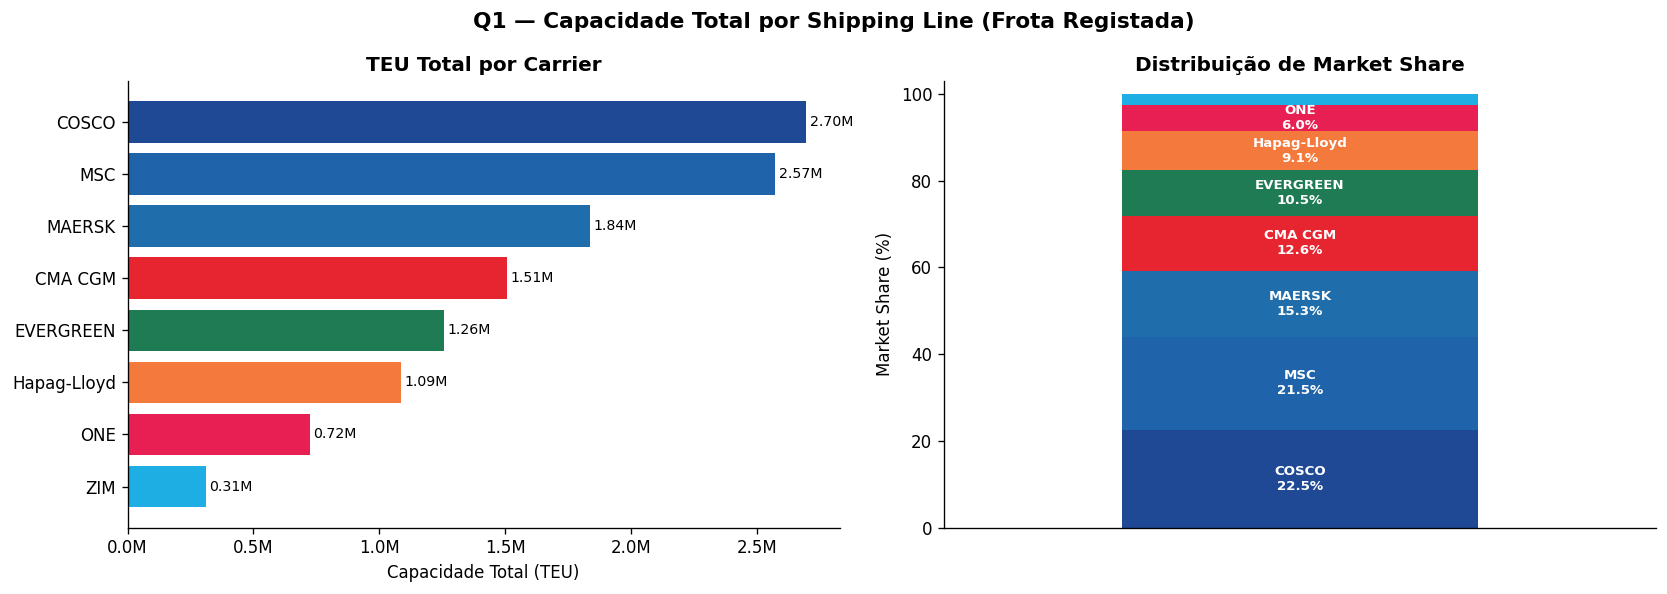

In [8]:
q1_plot = q1.sort_values('teu_total', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q1 — Capacidade Total por Shipping Line (Frota Registada)',
             fontsize=13, fontweight='bold')

carriers_q1 = q1_plot.index.tolist()
colors_q1   = [CORES.get(c, '#888888') for c in carriers_q1]
y_pos       = range(len(carriers_q1))

bars = ax1.barh(list(y_pos), q1_plot['teu_total'], color=colors_q1, alpha=0.88)
ax1.set_yticks(list(y_pos))
ax1.set_yticklabels(carriers_q1)
ax1.set_xlabel('Capacidade Total (TEU)')
ax1.set_title('TEU Total por Carrier')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v/1e6:.1f}M'))
for bar, val in zip(bars, q1_plot['teu_total']):
    ax1.text(bar.get_width() + 15000, bar.get_y() + bar.get_height() / 2,
             f'{val/1e6:.2f}M', va='center', fontsize=8.5)

bottom = 0
for c, row in q1.iterrows():
    pct = row['market_share_pct']
    ax2.bar(0, pct, bottom=bottom, color=CORES.get(c, '#888'), alpha=0.88,
            label=f'{c} ({pct:.1f}%)', width=0.5)
    if pct > 3:
        ax2.text(0, bottom + pct / 2, f'{c}\n{pct:.1f}%',
                 ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += pct

ax2.set_xlim(-0.5, 0.5)
ax2.set_xticks([])
ax2.set_ylabel('Market Share (%)')
ax2.set_title('Distribuição de Market Share')
ax2.set_ylim(0, 103)

plt.tight_layout()
plt.show()

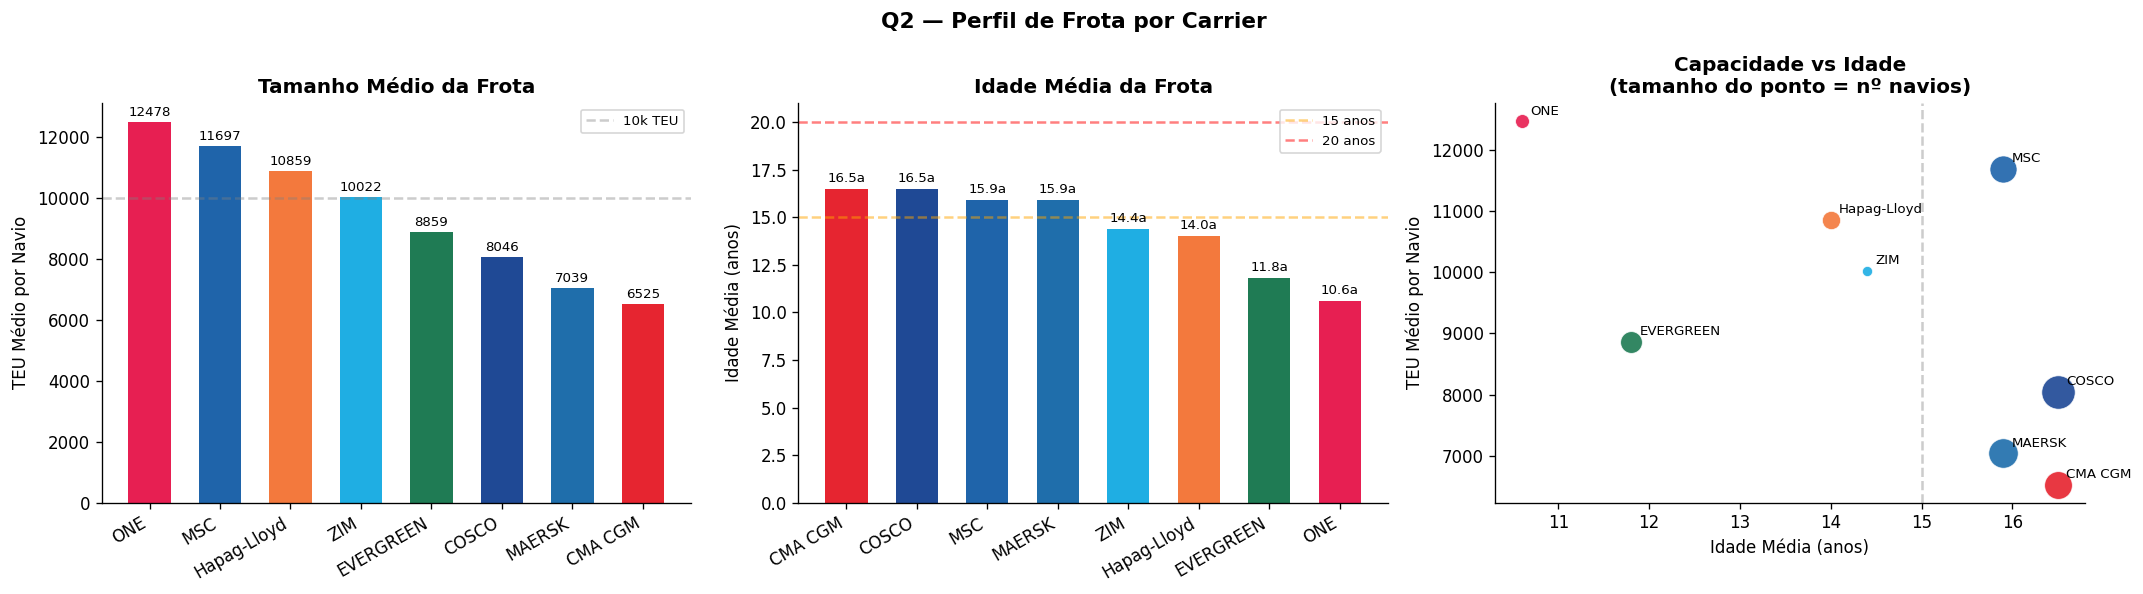

In [9]:
q2_teu = q2.sort_values('teu_medio', ascending=False)
q2_age = q2.sort_values('idade_media', ascending=False)

carriers_order_q2 = q2_teu.index.tolist()
colors_q2 = [CORES.get(c, '#888888') for c in carriers_order_q2]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Q2 — Perfil de Frota por Carrier', fontsize=13, fontweight='bold')

# TEU médio
x_q2 = np.arange(len(carriers_order_q2))
bars1 = axes[0].bar(x_q2, q2_teu['teu_medio'], color=colors_q2, alpha=0.88, width=0.6)
axes[0].set_xticks(x_q2)
axes[0].set_xticklabels(carriers_order_q2, rotation=30, ha='right')
axes[0].set_ylabel('TEU Médio por Navio')
axes[0].set_title('Tamanho Médio da Frota')
axes[0].axhline(10000, color='gray', linestyle='--', alpha=0.4, label='10k TEU')
axes[0].legend(fontsize=8)
for bar, val in zip(bars1, q2_teu['teu_medio']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=8)

# Idade média
carriers_age = q2_age.index.tolist()
colors_age   = [CORES.get(c, '#888888') for c in carriers_age]
x_age = np.arange(len(carriers_age))
bars2 = axes[1].bar(x_age, q2_age['idade_media'], color=colors_age, alpha=0.88, width=0.6)
axes[1].set_xticks(x_age)
axes[1].set_xticklabels(carriers_age, rotation=30, ha='right')
axes[1].set_ylabel('Idade Média (anos)')
axes[1].set_title('Idade Média da Frota')
axes[1].axhline(15, color='orange', linestyle='--', alpha=0.5, label='15 anos')
axes[1].axhline(20, color='red',    linestyle='--', alpha=0.5, label='20 anos')
axes[1].legend(fontsize=8)
for bar, val in zip(bars2, q2_age['idade_media']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                 f'{val:.1f}a', ha='center', va='bottom', fontsize=8)

# Bubble chart: idade vs TEU
for c, row in q2.iterrows():
    axes[2].scatter(row['idade_media'], row['teu_medio'],
                    s=row['n_navios'] * 1.2, color=CORES.get(c, '#888'),
                    alpha=0.8, edgecolors='white', linewidth=0.5)
    axes[2].annotate(c, (row['idade_media'], row['teu_medio']),
                     textcoords='offset points', xytext=(5, 4), fontsize=8)
axes[2].set_xlabel('Idade Média (anos)')
axes[2].set_ylabel('TEU Médio por Navio')
axes[2].set_title('Capacidade vs Idade\n(tamanho do ponto = nº navios)')
axes[2].axvline(15, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

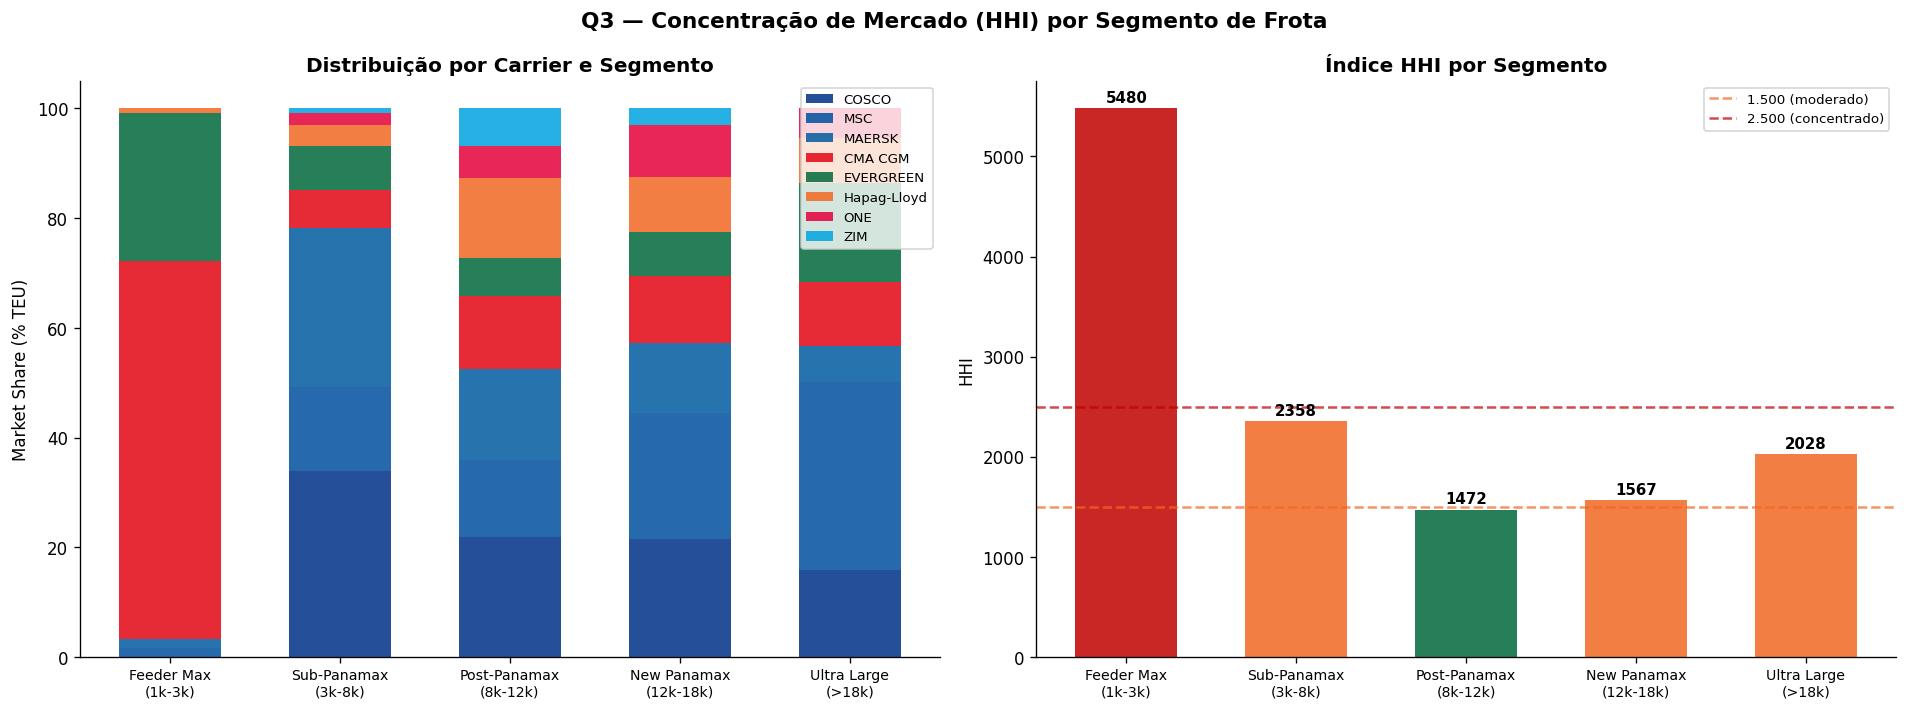

In [10]:
seg_order = ['Feeder Max (1k-3k TEU)', 'Sub-Panamax (3k-8k TEU)',
             'Post-Panamax (8k-12k TEU)', 'New Panamax (12k-18k TEU)',
             'Ultra Large (> 18k TEU)']
seg_labels = ['Feeder Max\n(1k-3k)', 'Sub-Panamax\n(3k-8k)',
              'Post-Panamax\n(8k-12k)', 'New Panamax\n(12k-18k)', 'Ultra Large\n(>18k)']

carriers_order_q3 = ['COSCO', 'MSC', 'MAERSK', 'CMA CGM', 'EVERGREEN', 'Hapag-Lloyd', 'ONE', 'ZIM']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q3 — Concentração de Mercado (HHI) por Segmento de Frota',
             fontsize=13, fontweight='bold')

x_q3   = np.arange(len(seg_order))
bottom = np.zeros(len(seg_order))

for c in carriers_order_q3:
    vals = []
    for seg in seg_order:
        row = seg_carrier[(seg_carrier['vessel_segment'] == seg) & (seg_carrier['SHIPPING LINE'] == c)]
        vals.append(row['share'].values[0] * 100 if len(row) > 0 else 0)
    ax1.bar(x_q3, vals, bottom=bottom, color=CORES.get(c, '#888'), alpha=0.85, label=c, width=0.6)
    bottom += np.array(vals)

ax1.set_xticks(x_q3)
ax1.set_xticklabels(seg_labels, fontsize=8.5)
ax1.set_ylabel('Market Share (% TEU)')
ax1.set_title('Distribuição por Carrier e Segmento')
ax1.legend(fontsize=8, loc='upper right')
ax1.set_ylim(0, 105)

hhi_vals   = [hhi[hhi['vessel_segment'] == s]['HHI'].values[0] for s in seg_order]
hhi_colors = ['#c00000' if h > 2500 else '#f26722' if h > 1500 else '#00693C' for h in hhi_vals]
bars_hhi   = ax2.bar(x_q3, hhi_vals, color=hhi_colors, alpha=0.85, width=0.6)
ax2.set_xticks(x_q3)
ax2.set_xticklabels(seg_labels, fontsize=8.5)
ax2.set_ylabel('HHI')
ax2.set_title('Índice HHI por Segmento')
ax2.axhline(1500, color='#f26722', linestyle='--', alpha=0.7, label='1.500 (moderado)')
ax2.axhline(2500, color='#c00000', linestyle='--', alpha=0.7, label='2.500 (concentrado)')
ax2.legend(fontsize=8)
for bar, val in zip(bars_hhi, hhi_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

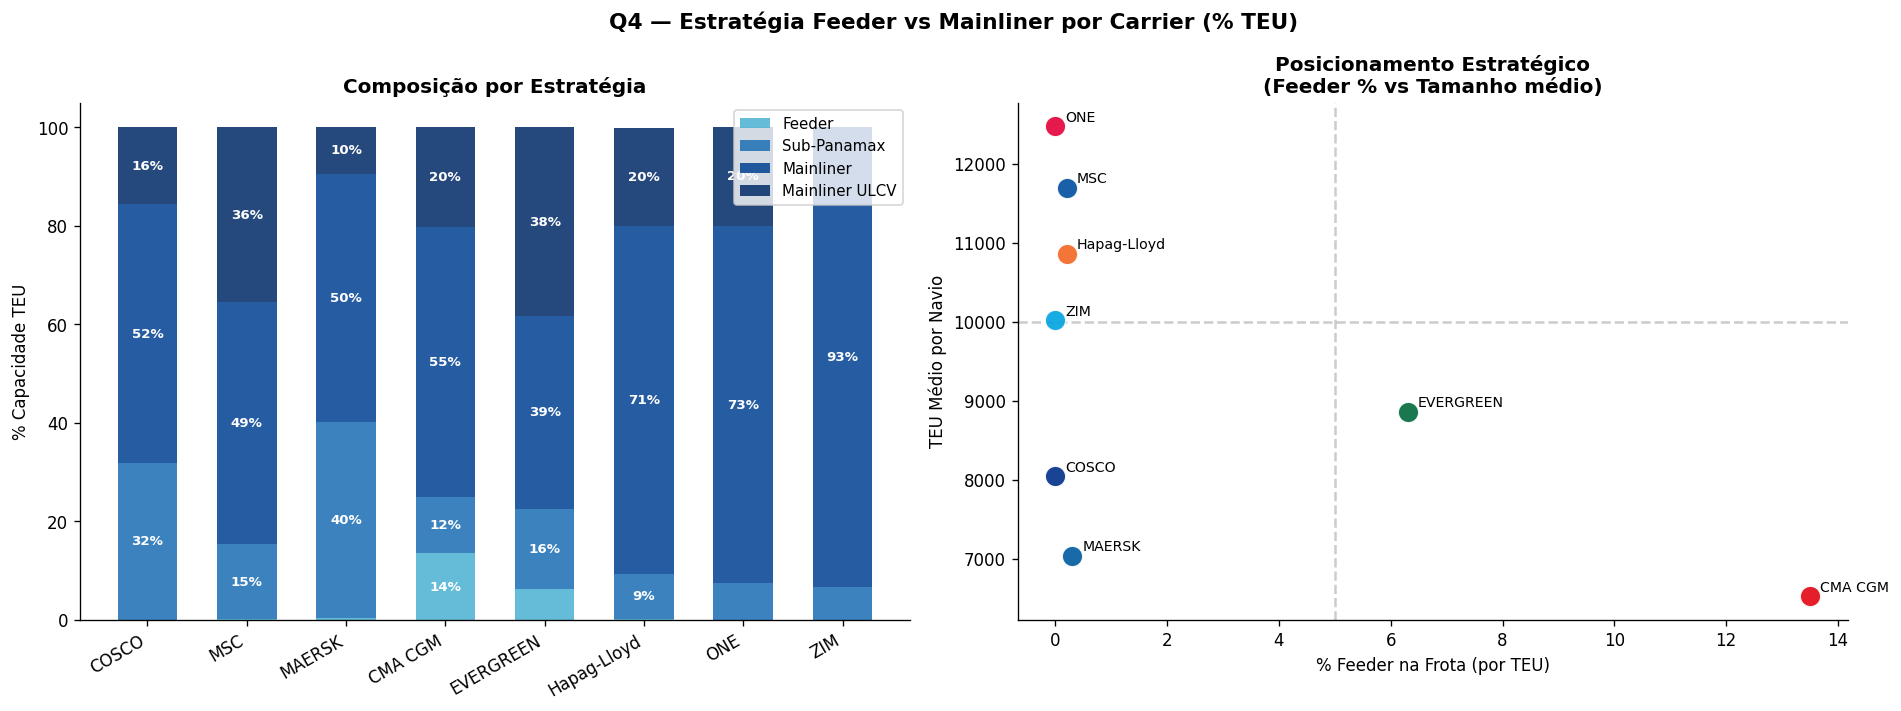

In [11]:
cats_q4  = ['Feeder', 'Sub-Panamax', 'Mainliner', 'Mainliner ULCV']
cols_q4  = ['#4EB3D3', '#2171B5', '#084594', '#08306B']
carriers_q4 = q4_piv.index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q4 — Estratégia Feeder vs Mainliner por Carrier (% TEU)',
             fontsize=13, fontweight='bold')

x_q4   = np.arange(len(carriers_q4))
bottom = np.zeros(len(carriers_q4))

for cat, col in zip(cats_q4, cols_q4):
    col_name = f'pct_{cat}'
    if col_name in q4_piv.columns:
        vals = q4_piv[col_name].values
        bars = ax1.bar(x_q4, vals, bottom=bottom, color=col, alpha=0.88, label=cat, width=0.6)
        for i, (bar, val) in enumerate(zip(bars, vals)):
            if val > 8:
                ax1.text(bar.get_x() + bar.get_width() / 2, bottom[i] + val / 2,
                         f'{val:.0f}%', ha='center', va='center',
                         fontsize=8, color='white', fontweight='bold')
        bottom += vals

ax1.set_xticks(x_q4)
ax1.set_xticklabels(carriers_q4, rotation=30, ha='right')
ax1.set_ylabel('% Capacidade TEU')
ax1.set_title('Composição por Estratégia')
ax1.legend(fontsize=9, loc='upper right')
ax1.set_ylim(0, 105)

q2_teu_medio  = df.groupby('SHIPPING LINE')['CAPACIDADE (TEU)'].mean()
feeder_pct_q4 = q4_piv['pct_Feeder'] if 'pct_Feeder' in q4_piv.columns else pd.Series(0, index=q4_piv.index)

for c in carriers_q4:
    ax2.scatter(feeder_pct_q4.get(c, 0), q2_teu_medio.get(c, 0),
                s=150, color=CORES.get(c, '#888'), alpha=0.9,
                edgecolors='white', linewidth=0.8, zorder=3)
    ax2.annotate(c, (feeder_pct_q4.get(c, 0), q2_teu_medio.get(c, 0)),
                 textcoords='offset points', xytext=(6, 3), fontsize=8.5)

ax2.set_xlabel('% Feeder na Frota (por TEU)')
ax2.set_ylabel('TEU Médio por Navio')
ax2.set_title('Posicionamento Estratégico\n(Feeder % vs Tamanho médio)')
ax2.axvline(5,     color='gray', linestyle='--', alpha=0.4)
ax2.axhline(10000, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()